In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [3]:
home= "Genoa"
away= "Empoli"

In [4]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Genoa,Monza,2025-01-27,W,H,2,0,2,50,1,...,1.6,1.1,-0.6,0.1,0.4,0.11,0,0.0,0.03,0.0
22,Genoa,Fiorentina,2025-02-02,L,A,1,2,-1,59,0,...,1.5,1.3,-0.6,-0.6,-0.5,0.09,1,1.2,0.24,-0.8
23,Genoa,Torino,2025-02-08,D,A,1,1,0,43,0,...,0.2,0.3,0.7,0.7,0.8,0.05,0,0.5,0.16,0.5
24,Genoa,Venezia,2025-02-17,W,H,2,0,2,51,0,...,1.4,0.8,0.5,0.5,0.6,0.11,0,0.3,0.09,0.3
25,Genoa,Inter,2025-02-22,L,A,0,1,-1,38,0,...,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,1.8,0.45,0.8


In [5]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Monza,Genoa,2025-01-27,L,A,0,2,-2,50,0,...,0.4,0.5,-0.4,-0.4,-0.4,0.09,0,3.2,0.41,1.2
22,Fiorentina,Genoa,2025-02-02,W,H,2,1,1,41,0,...,0.7,0.2,1.3,1.3,1.3,0.10,0,1.3,0.44,0.3
23,Torino,Genoa,2025-02-08,D,H,1,1,0,57,0,...,0.6,0.9,-0.7,-0.7,-0.6,0.07,0,0.4,0.20,-0.6
24,Venezia,Genoa,2025-02-17,L,A,0,2,-2,49,0,...,0.2,0.2,-0.5,-0.5,-0.2,0.07,1,1.9,0.39,-0.1
25,Inter,Genoa,2025-02-22,W,H,1,0,1,62,0,...,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1.1,0.53,1.1


In [6]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Empoli,Bologna,2025-01-25,D,H,1,1,0,37,0,...,0.6,0.9,0.4,0.4,0.4,0.11,0,1.5,0.19,0.5
22,Empoli,Juventus,2025-02-02,L,A,1,4,-3,45,0,...,0.2,0.1,0.2,0.2,-0.2,0.08,0,2.8,0.35,-1.2
23,Empoli,Milan,2025-02-08,L,H,0,2,-2,39,0,...,0.5,0.4,-0.7,-0.7,-0.5,0.09,0,1.3,0.26,-0.7
24,Empoli,Udinese,2025-02-16,L,A,0,3,-3,44,0,...,1.6,1.2,-2.1,-2.1,-1.6,0.14,1,2.5,0.35,-0.5
25,Empoli,Atalanta,2025-02-23,L,H,0,5,-5,46,0,...,0.8,0.7,-0.9,-0.9,-0.8,0.09,1,3.1,0.43,-0.9


In [7]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Bologna,Empoli,2025-01-25,D,A,1,1,0,63,0,...,0.6,0.8,0.3,0.3,0.4,0.07,0,0.5,0.49,-0.5
22,Juventus,Empoli,2025-02-02,W,H,4,1,3,55,0,...,1.3,1.1,2.2,2.2,0.7,0.08,2,0.7,0.22,-0.3
23,Milan,Empoli,2025-02-08,W,A,2,0,2,61,0,...,1.1,0.6,0.7,0.7,0.9,0.08,1,0.0,NaN,0.0
24,Udinese,Empoli,2025-02-16,W,H,3,0,3,56,0,...,1.8,1.3,0.7,0.7,0.2,0.14,0,1.0,0.27,1.0
25,Atalanta,Empoli,2025-02-23,W,A,5,0,5,54,0,...,1.8,1.0,1.9,1.9,2.2,0.16,0,0.1,0.08,0.1


In [8]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [9]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [10]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,2,0,1,50,1,14,4,28.6,5,35.7,...,2.2,1.4,1.6,1.1,-0.6,0.1,0.4,0.11,0,2
22,1,0,0,59,0,14,5,35.7,7,50.0,...,0.8,0.8,1.5,1.3,-0.6,-0.6,-0.5,0.09,1,1
23,1,0,0,43,0,16,5,31.3,11,68.8,...,-0.4,-0.4,0.2,0.3,0.7,0.7,0.8,0.05,0,1
24,2,0,0,51,0,22,9,40.9,12,54.5,...,1.0,1.0,1.4,0.8,0.5,0.5,0.6,0.11,0,2
25,0,0,0,38,0,9,6,66.7,2,22.2,...,-0.2,-0.2,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,0


In [11]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,0,0,0,50,0,15,4,26.7,10,66.7,...,-2.2,-1.4,0.4,0.5,-0.4,-0.4,-0.4,0.09,0,0
22,2,0,0,41,0,11,5,45.5,2,18.2,...,-0.8,-0.8,0.7,0.2,1.3,1.3,1.3,0.10,0,2
23,0,0,0,57,0,16,7,43.8,8,50.0,...,0.4,0.4,0.6,0.9,-0.7,-0.7,-0.6,0.07,0,1
24,0,0,0,49,0,23,7,30.4,14,60.9,...,-1.0,-1.0,0.2,0.2,-0.5,-0.5,-0.2,0.07,1,0
25,1,0,0,62,0,13,5,38.5,5,38.5,...,0.2,0.2,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1


In [12]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,37,0,8,5,62.5,2,25.0,...,-0.1,-0.1,0.6,0.9,0.4,0.4,0.4,0.11,0,1
22,1,0,0,45,0,18,8,44.4,8,44.4,...,-1.1,-1.1,0.2,0.1,0.2,0.2,-0.2,0.08,0,1
23,0,0,0,39,0,16,6,37.5,9,56.3,...,-0.6,-0.6,0.5,0.4,-0.7,-0.7,-0.5,0.09,0,0
24,0,0,0,44,0,15,7,46.7,7,46.7,...,-0.1,-0.1,1.6,1.2,-2.1,-2.1,-1.6,0.14,1,0
25,0,0,0,46,0,7,1,14.3,4,57.1,...,-1.2,-1.2,0.8,0.7,-0.9,-0.9,-0.8,0.09,1,0


In [13]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,63,0,11,2,18.2,5,45.5,...,0.1,0.1,0.6,0.8,0.3,0.3,0.4,0.07,0,1
22,4,0,0,55,0,24,10,41.7,10,41.7,...,1.1,1.1,1.3,1.1,2.2,2.2,0.7,0.08,2,4
23,2,0,0,61,0,25,12,48.0,13,52.0,...,0.6,0.6,1.1,0.6,0.7,0.7,0.9,0.08,1,2
24,3,0,0,56,0,21,11,52.4,9,42.9,...,0.1,0.1,1.8,1.3,0.7,0.7,0.2,0.14,0,3
25,4,0,0,54,0,20,10,50.0,6,30.0,...,1.2,1.2,1.8,1.0,1.9,1.9,2.2,0.16,0,5


## Defence

In [14]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [15]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,10,1,10.0,0,0,6.0,0,NaN,0,0,...,3,12,7,28,12,0,0.0,0.03,0.0,0
22,3,1,33.3,0,1,14.8,0,NaN,0,0,...,2,2,2,12,8,0,1.2,0.24,-0.8,2
23,16,0,0.0,0,0,12.7,0,NaN,0,0,...,3,13,8,28,29,0,0.5,0.16,0.5,1
24,9,3,33.3,0,0,6.2,0,NaN,0,0,...,1,11,9,41,18,0,0.3,0.09,0.3,0
25,17,2,11.8,0,0,6.3,0,NaN,0,1,...,8,11,8,21,42,0,1.8,0.45,0.8,1


In [16]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,19,0,0.0,1,1,22.0,1,100.0,0,1,...,6,5,8,17,39,0,3.2,0.41,1.2,2
22,25,0,0.0,0,2,27.0,0,NaN,0,1,...,3,6,7,24,42,0,1.3,0.44,0.3,1
23,7,1,14.3,0,4,20.1,0,NaN,0,0,...,2,5,7,22,17,1,0.4,0.20,-0.6,1
24,10,1,10.0,0,0,4.0,0,NaN,0,0,...,5,12,6,26,19,0,1.9,0.39,-0.1,2
25,20,1,5.0,0,1,23.5,0,NaN,0,0,...,5,9,7,15,28,1,1.1,0.53,1.1,0


In [17]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,0,3.0,0,NaN,0,0,...,3,6,4,21,21,0,0.1,0.14,0.1,0
1,26,2,7.7,0,0,5.2,0,NaN,0,0,...,10,10,6,27,37,0,1.5,0.23,0.5,1
2,21,1,4.8,0,2,16.4,0,NaN,0,1,...,2,6,12,30,48,0,0.3,0.12,-0.7,1
3,17,2,11.8,0,0,7.0,0,NaN,0,0,...,6,5,5,29,23,0,0.9,0.29,0.9,0
4,27,2,7.4,0,0,7.9,0,NaN,0,0,...,7,12,8,20,51,0,0.2,0.08,0.2,0


In [18]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,13,0,0.0,0,1,10.0,0,NaN,0,0,...,6,2,8,22,18,0,0.2,0.09,0.2,0
1,7,0,0.0,1,0,NaN,0,0.0,0,0,...,4,3,6,18,5,1,2.0,0.25,0.0,2
2,6,0,0.0,0,0,8.7,0,NaN,0,0,...,0,7,5,20,10,0,1.5,0.77,0.5,1
3,5,0,0.0,0,0,15.5,0,NaN,0,0,...,2,9,4,20,7,0,0.8,0.26,0.8,0
4,13,0,0.0,0,0,10.0,0,NaN,0,0,...,2,8,8,24,21,0,0.5,0.12,-1.5,2


## Combined

In [19]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [20]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,22,21,51.2,0,0,0,13,19,34
22,9,17,34.6,1,0,0,14,13,45
23,20,16,55.6,2,0,0,10,11,44
24,31,15,67.4,1,0,0,14,15,47
25,17,35,32.7,2,0,0,14,6,49


In [21]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,21,22,48.8,4,0,0,19,13,28
22,17,9,65.4,3,0,0,17,13,30
23,16,20,44.4,2,0,0,11,10,52
24,15,31,32.6,1,0,0,15,13,40
25,35,17,67.3,0,0,0,7,14,47


In [22]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,15,22,40.5,3,0,0,25,12,44
22,9,23,28.1,3,1,1,13,12,37
23,10,6,62.5,2,1,0,17,9,46
24,13,18,41.9,0,0,0,17,12,42
25,19,12,61.3,0,0,0,4,15,49


In [23]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,22,15,59.5,0,0,0,13,23,40
22,23,9,71.9,0,0,0,14,12,51
23,6,10,37.5,4,1,1,10,17,45
24,18,13,58.1,0,0,0,12,17,45
25,12,19,38.7,1,0,0,17,4,51


## By Team

In [24]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [25]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,2,0,1,50,1,14,4,28.6,5,35.7,...,-0.150,0.695222,-0.250,0.700000,0.1475,0.104682,0.00,0.0,1.00,0.816497
22,1,0,0,59,0,14,5,35.7,7,50.0,...,-0.175,0.680074,-0.025,0.736546,0.1425,0.106262,0.00,0.0,1.00,0.816497
23,1,0,0,43,0,16,5,31.3,11,68.8,...,-0.050,0.465475,0.125,0.450000,0.0900,0.016330,0.25,0.5,1.25,0.500000
24,2,0,0,51,0,22,9,40.9,12,54.5,...,0.175,0.573730,0.300,0.559762,0.0800,0.025820,0.25,0.5,1.25,0.500000
25,0,0,0,38,0,9,6,66.7,2,22.2,...,0.175,0.573730,0.325,0.573730,0.0900,0.028284,0.25,0.5,1.50,0.577350


In [26]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,0,0,0,50,0,15,4,26.7,10,66.7,...,-0.050,0.525991,-0.125,0.450000,0.0700,0.033665,1.00,0.816497,1.00,1.414214
22,2,0,0,41,0,11,5,45.5,2,18.2,...,-0.250,0.443471,-0.350,0.173205,0.0800,0.031623,0.75,0.957427,0.75,1.500000
23,0,0,0,57,0,16,7,43.8,8,50.0,...,0.225,0.809835,0.075,0.834166,0.0900,0.029439,0.50,1.000000,1.25,1.500000
24,0,0,0,49,0,23,7,30.4,14,60.9,...,0.150,0.896289,0.050,0.858293,0.0950,0.020817,0.50,1.000000,1.50,1.290994
25,1,0,0,62,0,13,5,38.5,5,38.5,...,-0.075,0.925113,0.025,0.865544,0.0825,0.015000,0.25,0.500000,0.75,0.957427


In [27]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,16,0,0.0,0,1,18.3,0,0.0,0,0,...,1.50,1.290994,1.650,0.714143,0.3025,0.112361,-0.600,0.627163,2.25,0.957427
22,19,0,0.0,0,0,10.0,0,0.0,0,0,...,1.00,1.414214,1.475,0.613052,0.2375,0.062915,-0.525,0.758837,2.00,1.154701
23,9,0,0.0,0,0,3.0,0,0.0,0,0,...,1.75,2.061553,2.025,0.550000,0.2800,0.068313,-0.725,0.818026,2.75,1.258306
24,17,0,0.0,0,2,14.5,0,0.0,0,1,...,1.00,2.000000,1.875,0.665207,0.2675,0.065511,-0.625,0.780491,2.50,1.290994
25,14,0,0.0,0,0,14.4,0,0.0,0,1,...,1.00,2.000000,2.025,0.736546,0.2875,0.077621,-0.475,0.713559,2.50,1.290994


In [28]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,10,0,0.0,0,0,8.0,0,0.0,0,0,...,1.00,0.816497,1.625,0.722842,0.390000,0.182939,0.625,0.722842,1.00,0.00000
22,11,0,0.0,0,0,4.0,0,0.0,0,1,...,0.75,0.957427,1.175,0.722842,0.462500,0.133260,0.175,0.722842,1.00,0.00000
23,12,1,8.3,0,5,27.8,0,0.0,0,0,...,0.25,0.500000,0.900,0.605530,0.427500,0.179513,-0.100,0.605530,1.00,0.00000
24,14,0,0.0,0,0,16.0,0,0.0,0,0,...,0.00,0.000000,0.450,0.310913,0.450000,0.212838,-0.300,0.216025,0.75,0.50000
25,13,0,0.0,0,2,14.5,0,0.0,0,0,...,0.00,0.000000,0.550,0.420317,0.326667,0.143643,0.050,0.665833,0.50,0.57735


In [29]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,37,0,8,5,62.5,2,25.0,...,-0.050,0.660808,0.100,0.605530,0.0800,0.024495,0.75,0.50000,1.00,0.00000
22,1,0,0,45,0,18,8,44.4,8,44.4,...,-0.050,0.660808,0.075,0.585235,0.0950,0.017321,0.50,0.57735,1.00,0.00000
23,0,0,0,39,0,16,6,37.5,9,56.3,...,0.200,0.432049,0.175,0.450000,0.0900,0.018257,0.50,0.57735,1.00,0.00000
24,0,0,0,44,0,15,7,46.7,7,46.7,...,0.125,0.573730,0.100,0.547723,0.0875,0.017078,0.25,0.50000,0.75,0.50000
25,0,0,0,46,0,7,1,14.3,4,57.1,...,-0.550,1.138713,-0.475,0.838153,0.1050,0.026458,0.25,0.50000,0.50,0.57735


In [30]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,63,0,11,2,18.2,5,45.5,...,0.700,0.627163,0.750,1.340398,0.1100,0.014142,0.00,0.000000,2.25,0.957427
22,4,0,0,55,0,24,10,41.7,10,41.7,...,0.725,0.602080,0.975,1.117661,0.0950,0.017321,0.00,0.000000,2.00,1.154701
23,2,0,0,61,0,25,12,48.0,13,52.0,...,1.225,0.813941,1.225,0.805709,0.0900,0.018257,0.50,1.000000,2.75,1.258306
24,3,0,0,56,0,21,11,52.4,9,42.9,...,1.025,0.822091,0.925,0.556028,0.0850,0.017321,0.75,0.957427,2.50,1.290994
25,4,0,0,54,0,20,10,50.0,6,30.0,...,0.975,0.838153,0.550,0.310913,0.0925,0.032016,0.75,0.957427,2.50,1.290994


In [31]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,10,1,10.0,0,0,6.0,0,0.0,0,0,...,1.00,0.816497,1.700,0.668331,0.3400,0.117473,9.500000e-01,0.544671,1.00,1.414214
22,3,1,33.3,0,1,14.8,0,0.0,0,0,...,0.75,0.957427,1.125,0.921502,0.2975,0.192072,6.250000e-01,0.644851,0.75,1.500000
23,16,0,0.0,0,0,12.7,0,0.0,0,0,...,0.25,0.500000,1.200,0.909212,0.2850,0.194336,2.000000e-01,0.909212,1.25,1.500000
24,9,3,33.3,0,0,6.2,0,0.0,0,0,...,0.00,0.000000,0.975,0.953502,0.2100,0.158955,-2.500000e-02,0.556028,1.50,1.290994
25,17,2,11.8,0,0,6.3,0,0.0,0,1,...,0.00,0.000000,0.500,0.509902,0.1300,0.090554,8.326673e-17,0.571548,0.75,0.957427


In [32]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,19,0,0.0,1,1,22.0,1,100.0,0,1,...,0.50,1.0,0.825,0.950000,0.2075,0.164595,-0.175,0.411299,1.00,0.816497
22,25,0,0.0,0,2,27.0,0,0.0,0,1,...,0.00,0.0,1.075,1.438460,0.1975,0.145000,0.075,0.818026,1.00,0.816497
23,7,1,14.3,0,4,20.1,0,0.0,0,0,...,0.00,0.0,1.375,1.284199,0.2825,0.166808,0.125,0.826136,1.25,0.500000
24,10,1,10.0,0,0,4.0,0,0.0,0,0,...,0.25,0.5,1.300,1.344123,0.2900,0.160624,0.050,0.888819,1.25,0.500000
25,20,1,5.0,0,1,23.5,0,0.0,0,0,...,0.25,0.5,1.700,1.174734,0.3600,0.108628,0.200,0.761577,1.50,0.577350


In [33]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
21,22,21,51.2,0,0,0,13,19,34,16.75,...,0.0,0.0,0.0,0.0,12.50,2.081666,11.5,2.516611,41.00,1.825742
22,9,17,34.6,1,0,0,14,13,45,16.25,...,0.0,0.0,0.0,0.0,12.50,2.081666,12.5,4.434712,39.50,4.041452
23,20,16,55.6,2,0,0,10,11,44,14.00,...,0.0,0.0,0.0,0.0,12.25,1.707825,13.0,4.320494,40.25,4.856267
24,31,15,67.4,1,0,0,14,15,47,15.25,...,0.0,0.0,0.0,0.0,12.25,1.707825,13.5,3.785939,40.50,5.066228
25,17,35,32.7,2,0,0,14,6,49,20.50,...,0.0,0.0,0.0,0.0,12.75,1.892969,14.5,3.415650,42.50,5.802298


In [34]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
21,21,22,48.8,4,0,0,19,13,28,15.25,...,0.0,0.0,0.0,0.0,12.25,2.629956,12.25,1.707825,40.00,3.915780
22,17,9,65.4,3,0,0,17,13,30,16.75,...,0.0,0.0,0.0,0.0,13.00,4.082483,12.25,1.707825,37.50,7.325754
23,16,20,44.4,2,0,0,11,10,52,16.00,...,0.0,0.0,0.0,0.0,14.50,4.203173,12.00,1.414214,34.75,7.632169
24,15,31,32.6,1,0,0,15,13,40,15.75,...,0.0,0.0,0.0,0.0,14.75,3.862210,12.00,1.414214,38.75,11.644026
25,35,17,67.3,0,0,0,7,14,47,17.25,...,0.0,0.0,0.0,0.0,15.50,3.415650,12.25,1.500000,37.50,11.000000


In [35]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
21,15,22,40.5,3,0,0,25,12,44,17.50,...,0.00,0.00000,0.00,0.0,12.50,3.109126,14.00,4.163332,46.50,11.958261
22,9,23,28.1,3,1,1,13,12,37,17.50,...,0.00,0.00000,0.00,0.0,14.75,7.135592,13.75,4.272002,48.00,10.862780
23,10,6,62.5,2,1,0,17,9,46,14.25,...,0.25,0.50000,0.25,0.5,14.50,7.187953,13.00,4.242641,42.25,8.139410
24,13,18,41.9,0,0,0,17,12,42,12.00,...,0.50,0.57735,0.25,0.5,16.00,6.831301,10.50,1.732051,40.50,5.322906
25,19,12,61.3,0,0,0,4,15,49,11.75,...,0.50,0.57735,0.25,0.5,18.00,5.033223,11.25,1.500000,42.25,3.862210


In [36]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
21,22,15,59.5,0,0,0,13,23,40,21.00,...,0.00,0.0,0.00,0.0,14.75,4.645787,11.75,2.986079,47.50,6.757712
22,23,9,71.9,0,0,0,14,12,51,20.50,...,0.00,0.0,0.00,0.0,14.75,4.645787,13.75,6.500000,47.50,6.757712
23,6,10,37.5,4,1,1,10,17,45,20.50,...,0.00,0.0,0.00,0.0,14.50,4.654747,13.50,6.557439,47.50,6.757712
24,18,13,58.1,0,0,0,12,17,45,17.25,...,0.25,0.5,0.25,0.5,11.75,2.061553,15.00,6.480741,45.00,4.546061
25,12,19,38.7,1,0,0,17,4,51,17.25,...,0.25,0.5,0.25,0.5,12.25,1.707825,17.25,4.500000,45.25,4.500000


In [37]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [38]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,38,0,9,6,66.7,2,22.2,...,2.0,2.025,0.736546,0.2875,0.077621,-0.475,0.713559,2.5,1.290994,H


In [39]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,1,32,1,15,9,60.0,4,26.7,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,A,1
1,1,0,0,31,0,10,3,30.0,7,70.0,...,0.0,0.0,16.0,0.000000,18.0,0.000000,41.000000,0.000000,H,0
2,0,0,0,58,0,12,4,33.3,7,58.3,...,0.0,0.0,13.5,3.535534,14.0,5.656854,36.500000,6.363961,H,1
3,1,0,0,48,0,10,4,40.0,4,40.0,...,0.0,0.0,15.0,3.605551,14.0,4.000000,34.666667,5.507571,A,0
4,0,0,0,51,0,9,3,33.3,6,66.7,...,0.0,0.0,14.0,3.559026,13.0,3.829708,36.500000,5.802298,H,0


In [40]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,17,2,11.8,0,0,6.3,0,0.0,0,1,...,0.57735,0.25,0.5,18.0,5.033223,11.25,1.5,42.25,3.86221,H


In [41]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,17,1,5.9,0,0,4.0,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,A,0
1,20,0,0.0,0,0,14.0,0,0.0,0,0,...,0.0,0.0,16.0,0.000000,18.0,0.000000,41.000000,0.000000,H,2
2,12,1,8.3,1,0,5.5,0,0.0,0,0,...,0.0,0.0,13.5,3.535534,14.0,5.656854,36.500000,6.363961,H,1
3,10,0,0.0,0,2,22.0,0,0.0,0,0,...,0.0,0.0,15.0,3.605551,14.0,4.000000,34.666667,5.507571,A,2
4,8,0,0.0,1,0,5.0,1,100.0,0,0,...,0.0,0.0,14.0,3.559026,13.0,3.829708,36.500000,5.802298,H,3


In [42]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,0,46,0,7,1,14.3,4,57.1,...,0.57735,0.25,0.5,18.0,5.033223,11.25,1.5,42.25,3.86221,A


In [43]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,39,0,16,6,37.5,8,50.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,A,2
1,1,1,0,27,1,9,4,44.4,3,33.3,...,0.0,0.0,16.0,0.000000,18.0,0.000000,41.000000,0.000000,A,1
2,1,0,0,31,0,24,13,54.2,4,16.7,...,0.0,0.0,13.5,3.535534,14.0,5.656854,36.500000,6.363961,H,0
3,0,0,0,35,0,13,3,23.1,8,61.5,...,0.0,0.0,15.0,3.605551,14.0,4.000000,34.666667,5.507571,A,2
4,2,0,0,39,0,10,5,50.0,5,50.0,...,0.0,0.0,14.0,3.559026,13.0,3.829708,36.500000,5.802298,H,0


In [44]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,14,0,0.0,0,0,14.4,0,0.0,0,1,...,0.57735,0.25,0.5,18.0,5.033223,11.25,1.5,42.25,3.86221,H


In [45]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,11,1,9.1,0,0,3.0,0,0.0,0,0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,A,1
1,26,2,7.7,0,0,5.2,0,0.0,0,0,...,0.0,0.0,16.0,0.000000,18.0,0.000000,41.000000,0.000000,A,1
2,21,1,4.8,0,2,16.4,0,0.0,0,1,...,0.0,0.0,13.5,3.535534,14.0,5.656854,36.500000,6.363961,H,0
3,17,2,11.8,0,0,7.0,0,0.0,0,0,...,0.0,0.0,15.0,3.605551,14.0,4.000000,34.666667,5.507571,A,0
4,27,2,7.4,0,0,7.9,0,0.0,0,0,...,0.0,0.0,14.0,3.559026,13.0,3.829708,36.500000,5.802298,H,0


In [46]:
df_home_gf = df_home_gf.fillna(0)

In [47]:
df_home_ga = df_home_ga.fillna(0)

In [48]:
df_away_ga = df_away_ga.fillna(0)

In [49]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [50]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [51]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [52]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [53]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [54]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

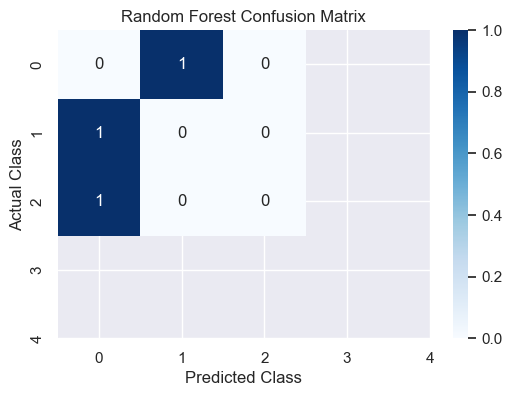

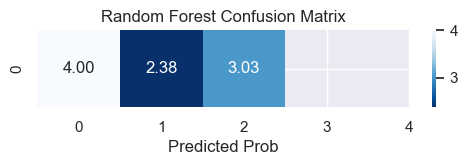

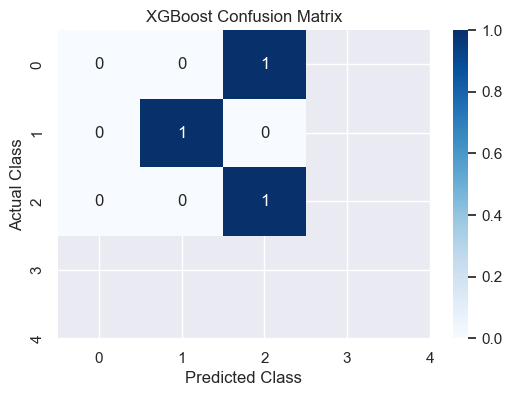

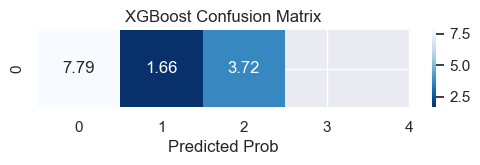

In [55]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Blues_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [56]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [57]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [58]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

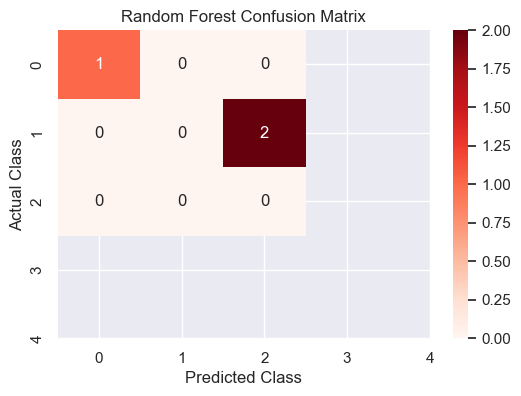

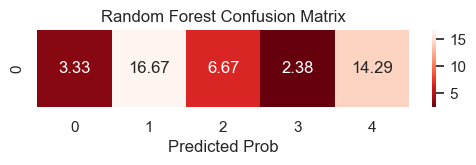

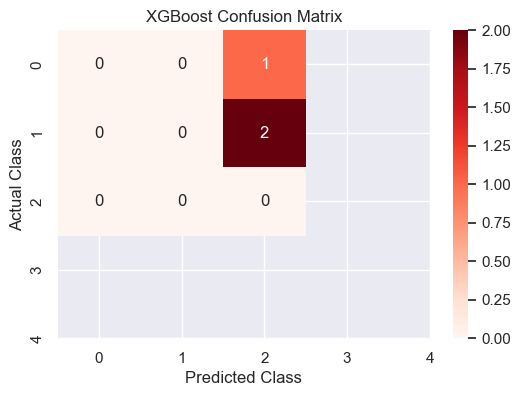

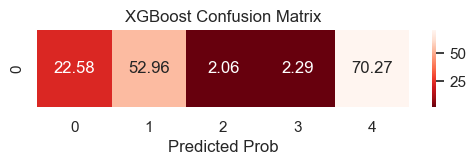

In [59]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Reds_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [60]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [61]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [62]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

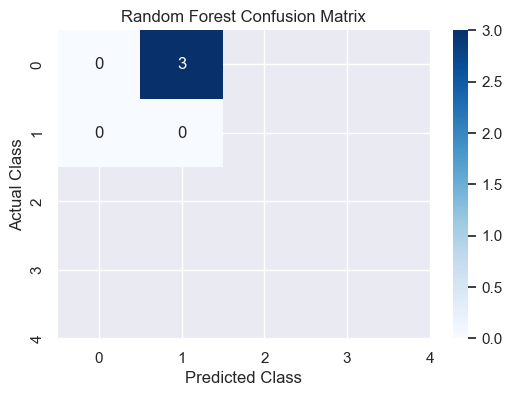

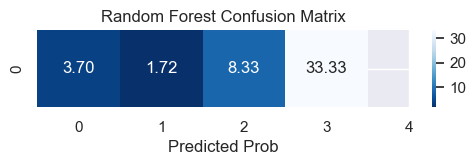

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 1 2 4]

In [63]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Blues_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [64]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [65]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [66]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

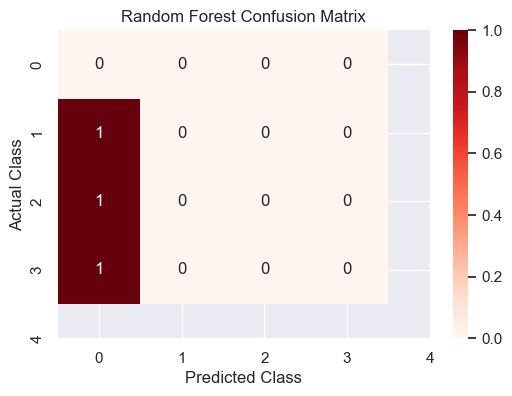

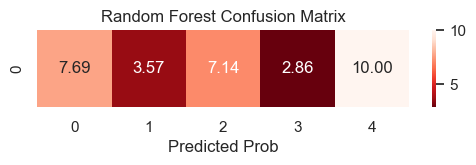

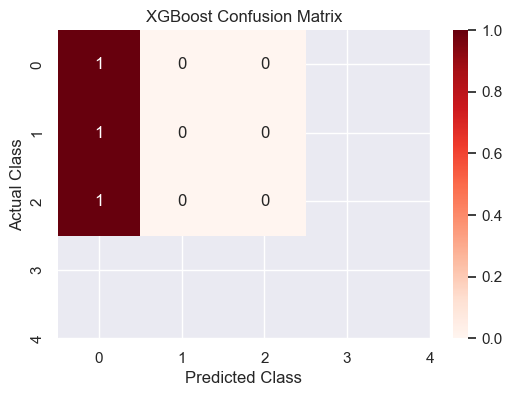

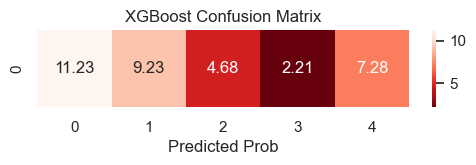

In [67]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(1/pred, annot=True, fmt='.2f', cmap='Reds_r', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

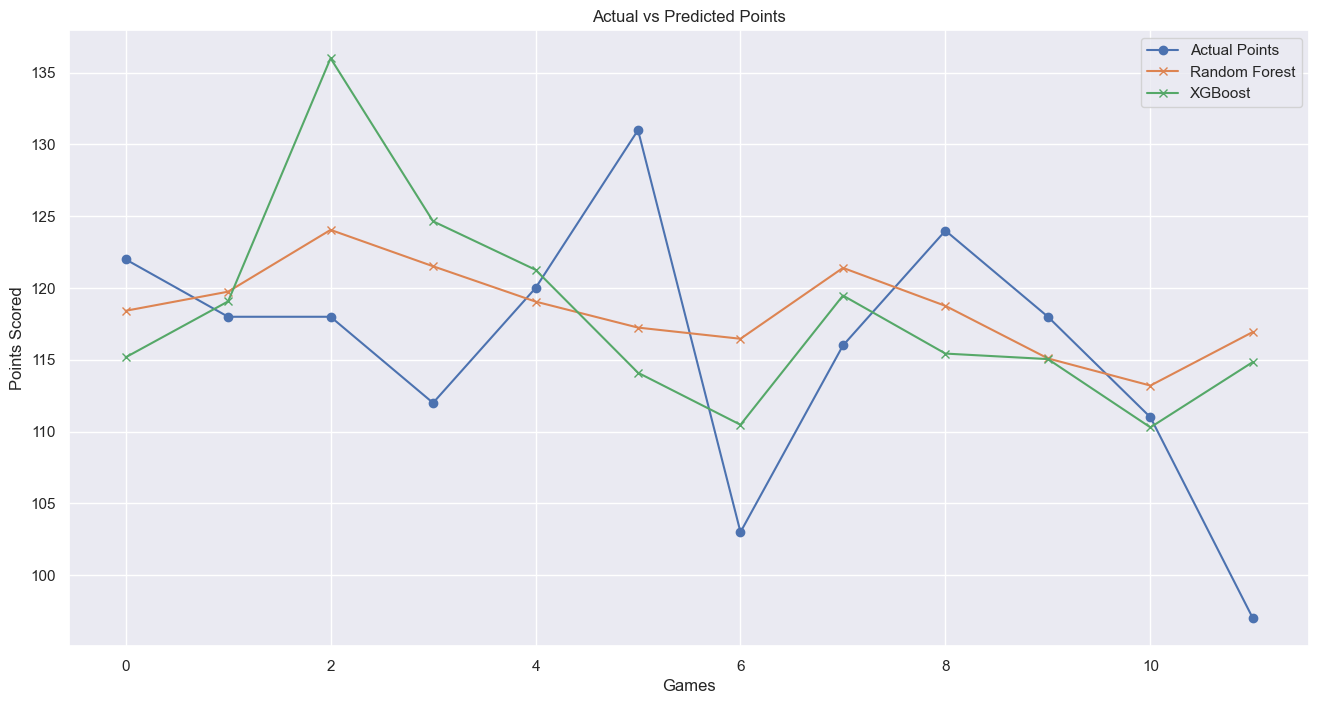

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
